**Aulas 09 - Aprendizado Ensemble e Florestas Aleaórias**

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/07_ensemble_learning_and_random_forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/07_ensemble_learning_and_random_forests.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

O projeto requer Python 3.7 ou acima:

In [3]:
import sys

assert sys.version_info >= (3, 7)

Também requer Scikit-Learn ≥ 1.0.1:

In [4]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Definindo as fontes dos gráficos, apenas para estética:

In [5]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Define a função `save_fig()`, que gravará as imagens geradas para os gráficos na pasta `images/ensembles`. Assim todas as imagens plotadas abaixo, ficam disponíveis para download.

In [6]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "ensembles"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# A Moeda Tendenciosa

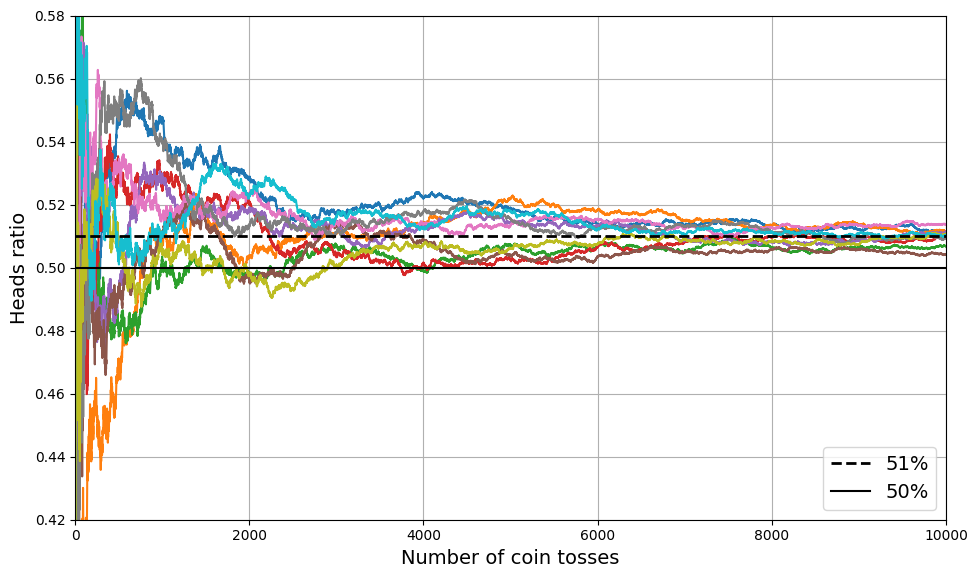

In [7]:
import matplotlib.pyplot as plt
import numpy as np

heads_proba = 0.51
np.random.seed(42)
coin_tosses = (np.random.rand(10000, 10) < heads_proba).astype(np.int32)
cumulative_heads = coin_tosses.cumsum(axis=0)
cumulative_heads_ratio = cumulative_heads / np.arange(1, 10001).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.plot(cumulative_heads_ratio)
plt.plot([0, 10000], [0.51, 0.51], "k--", linewidth=2, label="51%")
plt.plot([0, 10000], [0.5, 0.5], "k-", label="50%")
plt.xlabel("Number of coin tosses")
plt.ylabel("Heads ratio")
plt.legend(loc="lower right")
plt.axis([0, 10000, 0.42, 0.58])
plt.grid()
save_fig("law_of_large_numbers_plot")
plt.show()

# Classificador por Voto

Preparando um Classificador `VotingClassifier` composto pelos `estimators`:
 - `lr` → LogisticRegression
 - `rf` → RandomForestClassifier
 - `svc` → SVC

In [8]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(random_state=42))
    ]
)
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('svc', SVC(random_state=42))])

Observando a Acurácia dos modelos individualmente

In [9]:
for name, clf in voting_clf.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test))

lr = 0.864
rf = 0.896
svc = 0.896


In [10]:
voting_clf.predict(X_test[:1])

array([1])

In [11]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([1]), array([1]), array([0])]

Observando a Acurácia dos Ensemble com Votação Rígida (Hard Voting)

In [12]:
voting_clf.score(X_test, y_test)

0.912

Agora, observando a Acurácia dos Ensemble com Votação Suave (Soft Voting)

In [13]:
voting_clf.voting = "soft"
voting_clf.named_estimators["svc"].probability = True
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

0.92

### FIM DA 1ª DA DEMONSTRAÇÃO - voltar aos slides

# Bagging e Pasting

## Bagging e Pasting na Scikit-Learn

A Scikit-Learn disponibiliza as classes `BaggingClassifier`(classificação) e `BaggingRegressor`(regressão).

Para utilizar o Pasting, basta definir o parametro `bootstrap = False`.

In [14]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            max_samples=100, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=100,
                  n_estimators=500, n_jobs=-1, random_state=42)

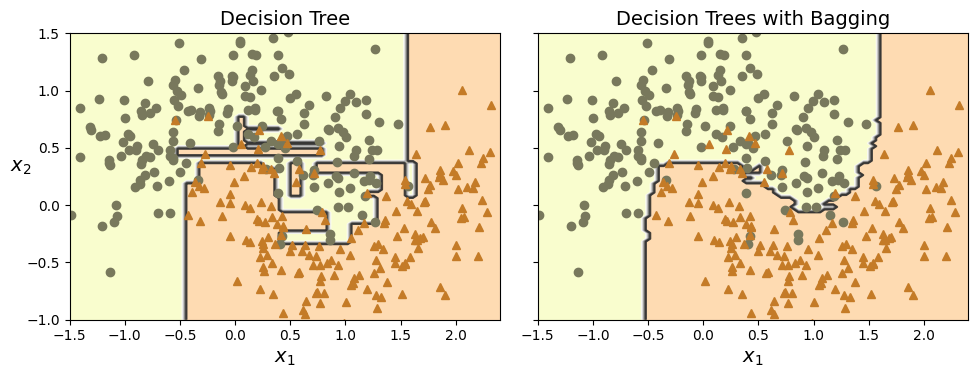

In [15]:
def plot_decision_boundary(clf, X, y, alpha=1.0):
    axes=[-1.5, 2.4, -1, 1.5]
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3 * alpha, cmap='Wistia')
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8 * alpha)
    colors = ["#78785c", "#c47b27"]
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf, X_train, y_train)
plt.title("Decision Tree")
plt.sca(axes[1])
plot_decision_boundary(bag_clf, X_train, y_train)
plt.title("Decision Trees with Bagging")
plt.ylabel("")
save_fig("decision_tree_without_and_with_bagging_plot")
plt.show()

## Avaliação Out-of-Bag (OOB)

Avaliação da Acurácia através de Avaliação OOB

In [16]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            oob_score=True, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.896

In [17]:
bag_clf.oob_decision_function_[:3]  # probas for the first 3 instances

array([[0.32352941, 0.67647059],
       [0.3375    , 0.6625    ],
       [1.        , 0.        ]])

Avaliação da Acurácia do modelo, contra os dados do Conjunto de Validação

In [18]:
from sklearn.metrics import accuracy_score

y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.92

# Florestas Aleatórias

In [19]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16,
                                 n_jobs=-1, random_state=42)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)

Uma Floresta Aleatória, é equivalente a um Bagging de Árvores de Decisão, seu seja, o bloco de código

```
rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16,
                                 n_jobs=-1, random_state=42)
```

equivale a

```
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes=16),
    n_estimators=500, n_jobs=-1, random_state=42)
```

In [20]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes=16),
    n_estimators=500, n_jobs=-1, random_state=42)

O código abaixo demonstra que as predições de ambos os modelos serão exatamente iguais

In [21]:
bag_clf.fit(X_train, y_train)
y_pred_bag = bag_clf.predict(X_test)
np.all(y_pred_bag == y_pred_rf)  # mesmas predições

np.True_

**IMPORTANTE** Também é possível treinar Florestas Aleatórias para resolver problemas de Regressão, utilizando a classe `RandomForestRegressor` do pacote `sklearn.ensemble`

## Importância das Características

Abaixo temos um modelo de Floresta Aleatória treinado para os dados do Dataset Iris.

Ao final, observe o Ranking da Importânicia das Características do Dataset no modelo treinado.

In [22]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris.data, iris.target)
for score, name in zip(rnd_clf.feature_importances_, iris.data.columns):
    print(round(score, 2), name)

0.11 sepal length (cm)
0.02 sepal width (cm)
0.44 petal length (cm)
0.42 petal width (cm)


Abaixo temos um modelo de Floresta Aleatória treinado para os dados do Dataset MNIST.

Ao final, temos um gráfico demonstrando um mapa de calor de quais são os pixels mais importantes para o modelo.

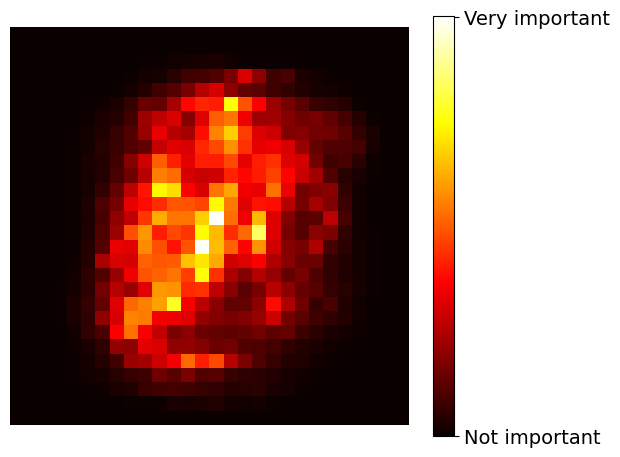

In [23]:
from sklearn.datasets import fetch_openml

X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True, as_frame=False,
                                parser='auto')

rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rnd_clf.fit(X_mnist, y_mnist)

heatmap_image = rnd_clf.feature_importances_.reshape(28, 28)
plt.imshow(heatmap_image, cmap="hot")
cbar = plt.colorbar(ticks=[rnd_clf.feature_importances_.min(),
                           rnd_clf.feature_importances_.max()])
cbar.ax.set_yticklabels(['Not important', 'Very important'], fontsize=14)
plt.axis("off")
save_fig("mnist_feature_importance_plot")
plt.show()

### FIM DA 2ª DA DEMONSTRAÇÃO - voltar aos slides

# Exercícios

Este exercício deve ser desenvolvido utilizando o conjunto de dados do MNIST, que pode ser carregado através do código abaixo.

```
from sklearn.datasets import fetch_openml

X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True, as_frame=False,
                                parser='auto')
```

Este Dataset contém 70.000 amostras de números escritos a mão (do 0 ao 9), em sua Característica `data`, há um array de 784 posições, que representa uma imagem de 28 x 28 pixels (28 * 28 = 784). É possível visualizar a imagem através das seguintes instruções.

```
# Pegando a primeira imagem do Vetor X, que é um vetor de 784 posições,
# transformando em uma matriz de 28x28 e recriando a imagem
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X_mnist[0]
plot_digit(some_digit)
save_fig("some_digit_plot")  # extra code
plt.show()
```

1. Carregue os dados do MNIST, e divida-os em um conjunto de treinamento (50 mil instâncias), validação (10 mil registros) e testes (10 mil registros). Prepare um Pipeline, treine uma Floresta Aleatória e apure a acurária para o seu modelo.

In [24]:
# RESOLUÇÃO EXERCÍCIO 1

2. Prepare novos Pipelines, com classificadores para este mesmo conjunto de treinamentos e calcule suas acurácias. Treine modelos para os algoritmos SVM, Árvore de Decisão e Regressão Logística, apure suas respectivas acurácias.

In [25]:
# RESOLUÇÃO EXERCÍCIO 2

3. Prepare um novo Pipeline, mas agora montando um Ensemble com todos os modelos desenvolvidos nos exercícios anteriores. Apure a acurácia do seu novo modelo, e compare com as acurácias dos modelos individuais.

In [26]:
# RESOLUÇÃO EXERCÍCIO 3

4. Avalie ajustar o seu Ensemble, mudando seu Tipo de Votação. Qual tipo possui a melhor acurácia?

In [27]:
# RESOLUÇÃO EXERCÍCIO 4

5. Finalmente, faça a validação da Acurácia de todos os seus modelos, mas desta vez contra o Conjunto de Dados de Teste. Observe o comportamento e capacidade de generalização de cada modelo.

In [28]:
# RESOLUÇÃO EXERCÍCIO 5